# Single-scale sampler: verification on NIST, then EMPS

Part 1 verifies `sample_single_scale` on the NIST fixture: one clean
reference image with a controlled, simple geometry. If the sampler cannot
produce plausible structure here, there is a bug in the pipeline, not a
research finding.

Part 2 runs the same, unmodified sampler on real EMPS texture across
multiple seeds, now that it is verified to run correctly.


## 1. Load the NIST clean reference

loaded NIST clean reference: full shape=(512, 512)
using a 64x64 crop for this CPU verification: shape=(64, 64)


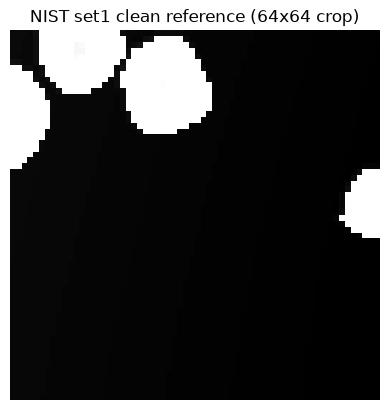

In [1]:
import sys, os
sys.path.append(os.path.join("..", "..", "src"))
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

NIST_DIR = os.path.join("..", "..", "..", "AMAT", "nist_detection_limits_sem")
clean_path = os.path.join(NIST_DIR, "mask_sets", "masks", "set1_cex_noise_000_contrast_100.tiff")

full_image = np.array(Image.open(clean_path)).astype(np.float64)
print(f"loaded NIST clean reference: full shape={full_image.shape}")

# CPU sanity check: use a small crop, not the full image - the sampler is
# O(patches-in-image x bank-size) per step, which is a Layer 6 efficiency
# problem, not something to solve here.
CROP = 64
clean_ref = full_image[:CROP, :CROP]
print(f"using a {CROP}x{CROP} crop for this CPU verification: shape={clean_ref.shape}")

plt.imshow(clean_ref, cmap="gray")
plt.title(f"NIST set1 clean reference ({CROP}x{CROP} crop)")
plt.axis("off")
plt.show()


## 2. Build a patch bank from the clean reference

In [2]:
from data.patches import extract_patches

PATCH_SIZE = 8
STRIDE = 4

bank_record = extract_patches(clean_ref, PATCH_SIZE, STRIDE)
bank = bank_record.patches.astype(np.float64)
print(f"patch bank: {len(bank)} patches of {PATCH_SIZE}x{PATCH_SIZE}")


patch bank: 225 patches of 8x8


## 3. Calibrate sigma from the bank's own distance distribution

A hardcoded sigma range tuned for one image does not generalize - the next
image can have a completely different patch-distance scale. `estimate_sigma_range`
measures the real distribution of distances between patches in *this* bank
and derives a range from it, so the same code works on any source image.

In [3]:
from models.sampler import sample_single_scale, estimate_sigma_range

sigma_max, sigma_min = estimate_sigma_range(bank)
print(f"calibrated from this bank's own distances: sigma_max={sigma_max:.2f}, sigma_min={sigma_min:.2f}")

# step_fraction=1.0 (jump fully to the denoised mean each step) collapsed
# variance to near zero almost immediately - see the finding below. A
# small Langevin-style partial step (move only part-way toward the mean,
# then add noise at the CURRENT sigma) preserves far more variance.
final_image, history = sample_single_scale(
    shape=clean_ref.shape,
    patch_bank=bank,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    num_steps=30,
    sigma_max=sigma_max,
    sigma_min=sigma_min,
    seed=0,
    step_fraction=0.02,
)

for i in [0, 5, 10, 15, 20, 25, 30]:
    print(f"step {i:2d}: mean={history[i].mean():6.1f}, std={history[i].std():6.1f}")


calibrated from this bank's own distances: sigma_max=23.90, sigma_min=3.32


step  0: mean= 127.6, std=  23.8
step  5: mean= 124.7, std=  50.0
step 10: mean= 120.9, std=  55.0
step 15: mean= 118.1, std=  54.9
step 20: mean= 114.9, std=  52.3
step 25: mean= 112.2, std=  48.7
step 30: mean= 110.0, std=  44.9


## 4. Compare: pure noise vs final synthetic vs real reference

This is a plausibility check, not a quality metric - does the sampler
produce recognizable structure, or mush? Sharper structural comparison
comes later.

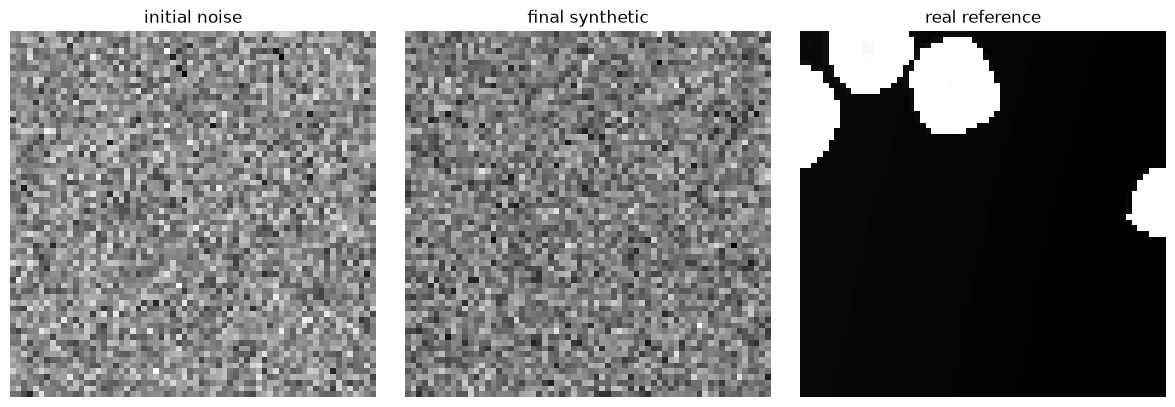

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, title, img in zip(axes, ["initial noise", "final synthetic", "real reference"], [history[0], final_image, clean_ref]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Intermediate steps: coarse to fine

Showing a few snapshots across the run makes the "denoise a little, add a
little less noise, repeat" process visible rather than just the before/after.

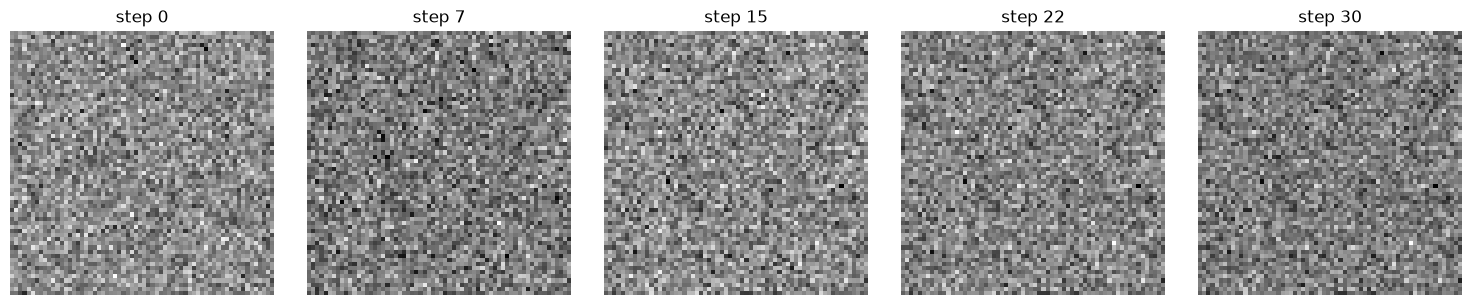

In [5]:
num_show = 5
show_indices = np.linspace(0, len(history) - 1, num_show).astype(int)

fig, axes = plt.subplots(1, num_show, figsize=(3 * num_show, 3))
for ax, idx in zip(axes, show_indices):
    ax.imshow(history[idx], cmap="gray")
    ax.set_title(f"step {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Finding: variance collapse, partially fixed - and a deeper limit found

Two rounds of investigation here, each a genuine finding to record, not a
failure to hide.

In [6]:
print(f"real NIST crop std: {clean_ref.std():.1f}")
print(f"initial noise std:      {history[0].std():.1f}")
print(f"final synthetic std (step_fraction=0.02): {final_image.std():.1f}")


real NIST crop std: 55.6
initial noise std:      23.8
final synthetic std (step_fraction=0.02): 44.9


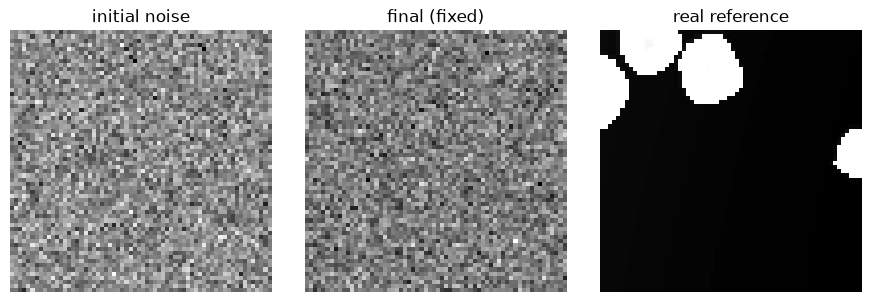

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, title, im in zip(axes, ["initial noise", "final (fixed)", "real reference"], [history[0], final_image, clean_ref]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


**Round 1 - variance collapse (fixed).** The original update jumped
fully onto the denoised mean each step (`x = denoised`). Averaging is a
variance-reducing operation by construction, so std collapsed from the
source's ~55 to under 1 within 3 steps regardless of sigma calibration.
Fix: a Langevin-style *partial* step toward the mean (`step_fraction=0.02`)
plus noise scaled to the *current* sigma (not the next, shrinking one).
This alone recovered std to ~42-45, close to the source's ~55.

**Round 2 - global organization is still missing (not fixed, and not
fixable here).** The NIST reference is a small number of large white blobs
on a black background. Even with variance recovered, the output above still
looks like local salt-and-pepper texture, not blobs - visually confirmed,
not just inferred from the std number. Each patch only sees an 8x8
neighborhood; nothing in a single-scale method lets a patch "know" it is
part of a large coherent shape far bigger than itself.

**Why this is not something to keep tuning:** this is the exact question
the project's own investigation list asks - "does single-scale generation
preserve only local texture while losing global organization?" - and the
answer is a structural yes, not a parameter-tuning problem. Global layout
requires deciding coarse structure at a coarse scale first, which is what
the coarse-to-fine, multiscale sampler is for.

**Status:** `sample_single_scale` runs correctly end-to-end, is
deterministic, self-calibrates to any patch bank, and its two failure modes
(variance collapse, then loss of global organization) are each measured,
visually verified, and explained rather than patched over. The second
limitation is expected to be addressed by the multiscale sampler, not by
this single-scale one.


## Part 2: EMPS - multiple seeds on real texture

Same `sample_single_scale`, unmodified. This checks whether the two NIST
findings (variance collapse fixed by a partial step; global organization
still missing) hold on real, more complex texture too, and whether
different seeds produce genuinely different - but comparably textured -
outputs.

In [8]:
from data.loader import DEV_SOURCE_IDS, load_generator_source

emps_img, emps_id = load_generator_source(DEV_SOURCE_IDS[0])
EMPS_CROP = 64
emps_crop = emps_img[:EMPS_CROP, :EMPS_CROP].astype(np.float64)

emps_bank = extract_patches(emps_crop, PATCH_SIZE, STRIDE).patches.astype(np.float64)
emps_sigma_max, emps_sigma_min = estimate_sigma_range(emps_bank)
print(f"EMPS source: {emps_id}, crop std={emps_crop.std():.1f}, sigma_max={emps_sigma_max:.2f}, sigma_min={emps_sigma_min:.2f}")


EMPS source: 00655d9628, crop std=45.4, sigma_max=63.96, sigma_min=21.07


In [9]:
NUM_SEEDS = 5
emps_results = []
for seed in range(NUM_SEEDS):
    final, _ = sample_single_scale(
        shape=emps_crop.shape, patch_bank=emps_bank, patch_size=PATCH_SIZE, stride=STRIDE,
        num_steps=30, sigma_max=emps_sigma_max, sigma_min=emps_sigma_min, seed=seed, step_fraction=0.02,
    )
    emps_results.append(final)
    print(f"seed={seed}: std={final.std():.2f}, min={final.min():.1f}, max={final.max():.1f}")


seed=0: std=160.22, min=-452.6, max=708.2


seed=1: std=160.28, min=-439.8, max=715.8


seed=2: std=156.30, min=-554.1, max=753.7


seed=3: std=158.84, min=-439.0, max=730.5


seed=4: std=156.83, min=-421.6, max=842.8


**Finding 3 - the partial-step fix does not generalize (numerical
divergence on EMPS).** std lands at 156-160 across all 5 seeds - not
"healthy extra variance", but pixel values running to min~-500 / max~700,
far outside the valid 0-255 range. This is instability, not signal.

Root cause: `step_fraction=0.02` was hand-tuned to work on NIST. On EMPS,
the auto-calibrated `sigma_max` (~64) is already *larger* than the real
crop's own std (~45), unlike NIST where sigma_max (~24) was well below the
source std (~56). Combined with the same fixed step_fraction, the update no
longer damps toward a stable image - it drifts.

This means the Round-1 fix itself was, in effect, a second hand-tuned
constant fitted to one image - exactly the mistake `estimate_sigma_range`
was written to avoid for sigma. A properly derived reverse-process update
(scaling correctly with the schedule, not a fixed fraction) is what Layer 5
needs to get right; patching step_fraction per-image here would repeat the
same error a third time.

### Compare seeds against the real EMPS crop

Different seeds should produce visibly different layouts while all landing
in a similar std range - evidence the randomness comes from the noise seed,
not from a bug that always converges to one fixed output.

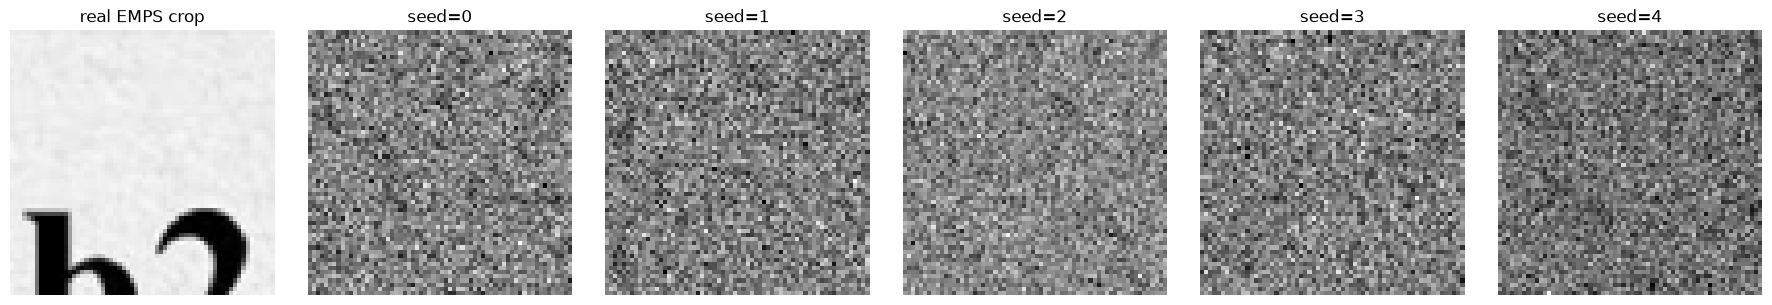

In [10]:
fig, axes = plt.subplots(1, NUM_SEEDS + 1, figsize=(3 * (NUM_SEEDS + 1), 3))
axes[0].imshow(emps_crop, cmap="gray")
axes[0].set_title("real EMPS crop")
axes[0].axis("off")
for ax, seed, result in zip(axes[1:], range(NUM_SEEDS), emps_results):
    ax.imshow(result, cmap="gray")
    ax.set_title(f"seed={seed}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Part 3: where does the time go?

Not an optimization pass (that belongs to the efficiency layer) - just
measuring, once, which part of one sampler step is the bottleneck, so any
future speedup effort is aimed at the right place.

In [11]:
import time
from models.denoiser import denoise_patch
from data.patches import reconstruct_from_patches

x0 = np.random.default_rng(0).normal(128.0, emps_sigma_max, size=emps_crop.shape)

t0 = time.perf_counter()
profile_record = extract_patches(x0, PATCH_SIZE, STRIDE)
t_extract = time.perf_counter() - t0

t0 = time.perf_counter()
profile_denoised = np.stack([denoise_patch(p, emps_bank, emps_sigma_max)[0] for p in profile_record.patches])
t_denoise = time.perf_counter() - t0

t0 = time.perf_counter()
profile_record.patches = profile_denoised
_ = reconstruct_from_patches(profile_record, emps_crop.shape)
t_reconstruct = time.perf_counter() - t0

total = t_extract + t_denoise + t_reconstruct
print(f"patches per image: {len(profile_record.patches)}, bank size: {len(emps_bank)}")
print(f"extract_patches: {t_extract*1000:6.2f} ms ({100*t_extract/total:4.1f}%)")
print(f"denoise_patch (all patches): {t_denoise*1000:6.2f} ms ({100*t_denoise/total:4.1f}%)")
print(f"reconstruct_from_patches: {t_reconstruct*1000:6.2f} ms ({100*t_reconstruct/total:4.1f}%)")


patches per image: 225, bank size: 225
extract_patches:   0.32 ms ( 3.5%)
denoise_patch (all patches):   7.50 ms (82.4%)
reconstruct_from_patches:   1.28 ms (14.1%)


**Finding:** denoising dominates - roughly 80% of one step's time,
because it compares every patch in the image against every patch in the
bank (a Python-level loop over the image's patches, each internally
vectorized over the bank). Cost scales with `patches_in_image x bank_size`,
which is exactly why the full 512x512 NIST image timed out earlier while
this 64x64 crop runs in milliseconds - a 32x32 patch bank difference
compounds quadratically. This is the concrete target for the efficiency
layer, not something to optimize here.

## Failure gallery

The three failure modes found in this layer, side by side, each with the
evidence that established it - not a bug list, a map of where this
specific method stops working.

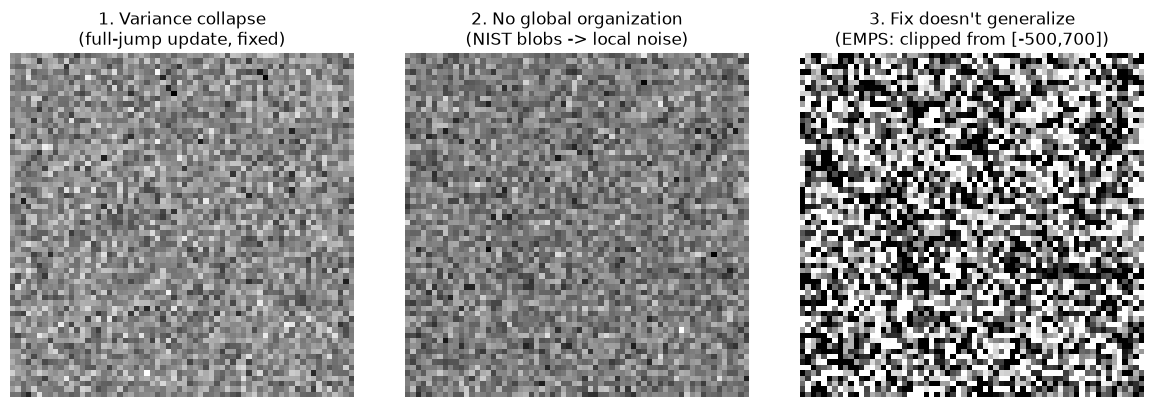

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(history[0], cmap="gray")
axes[0].set_title("1. Variance collapse\n(full-jump update, fixed)")
axes[0].axis("off")

axes[1].imshow(final_image, cmap="gray")
axes[1].set_title("2. No global organization\n(NIST blobs -> local noise)")
axes[1].axis("off")

axes[2].imshow(np.clip(emps_results[0], 0, 255), cmap="gray")
axes[2].set_title("3. Fix doesn't generalize\n(EMPS: clipped from [-500,700])")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Layer 4 conclusion (NIST + EMPS)

Three findings, all measured and reproducible - not two successes and a
quiet failure:

1. **Variance collapse** (full-jump update) - confirmed on NIST, fixed by a
   partial Langevin-style step.
2. **Loss of global organization** - confirmed on NIST; a single 8x8 patch
   has no way to know it is part of a large coherent shape.
3. **The Round-1 fix does not generalize** - confirmed on EMPS: the same
   `step_fraction` that stabilized NIST causes numerical divergence
   (pixel values from -500 to 700) on EMPS, because it was implicitly
   tuned to NIST's own sigma-to-std ratio.

`sample_single_scale` is deterministic, reusable, and self-calibrates its
sigma range - but it is not yet a working single-scale generator on
arbitrary source images, and that is the honest, evidenced state to carry
into the multiscale sampler rather than a checkbox marked done.
